loading annotations into memory...
Done (t=0.90s)
creating index...
index created!
Total images in dataset: 5000


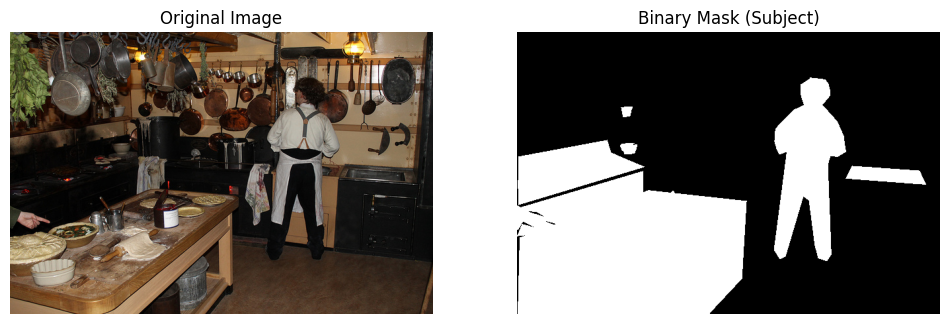

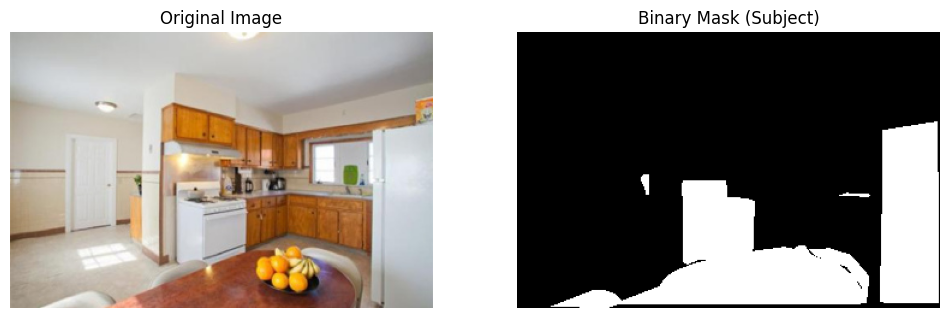

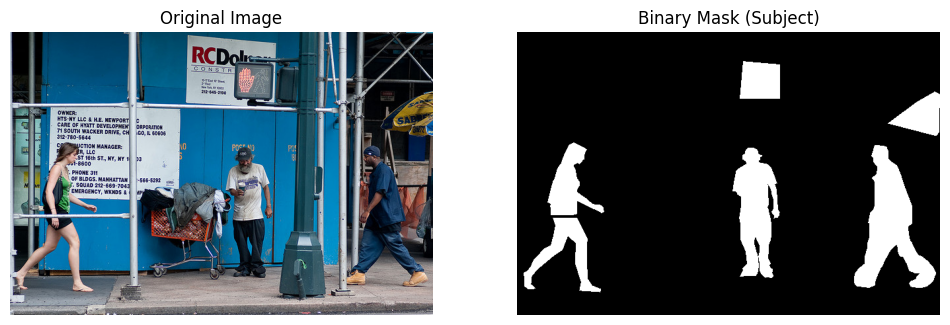

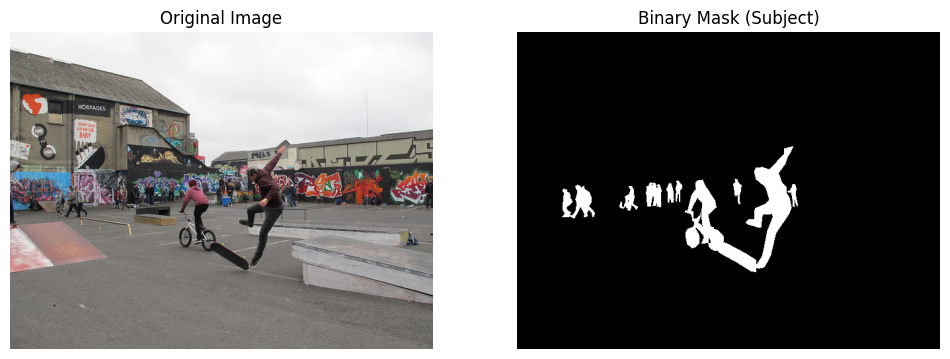

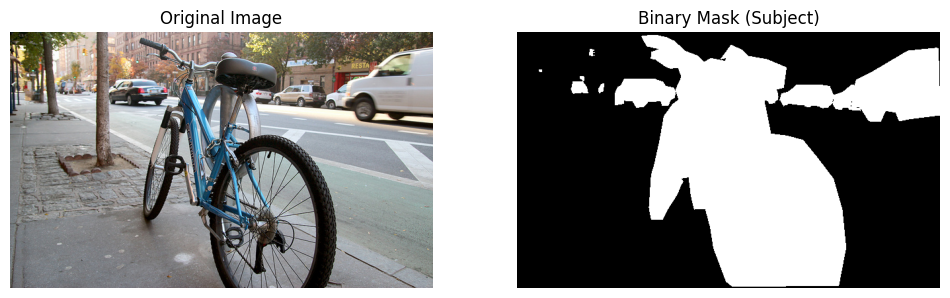

In [ ]:
#Week 1

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pycocotools.coco import COCO
from tensorflow.keras.preprocessing.image import ImageDataGenerator


DATA_ROOT = "/content/drive/MyDrive/VisionAI"
IMAGES_DIR = os.path.join(DATA_ROOT, "val2017")  # or train2017
ANN_FILE = os.path.join(DATA_ROOT, "annotations", "instances_val2017.json")

coco = COCO(ANN_FILE)
img_ids = coco.getImgIds()
print("Total images in dataset:", len(img_ids))

def build_binary_mask(coco, img_info):
    # Get all annotations for this image
    ann_ids = coco.getAnnIds(imgIds=img_info['id'], iscrowd=False)
    anns = coco.loadAnns(ann_ids)

    # Empty mask
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

    # Add each object’s mask
    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    # Convert to binary: 0 = background, 1 = subject
    mask = np.clip(mask, 0, 1)
    return mask

for img_id in img_ids[:5]:
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGES_DIR, img_info['file_name'])

    img = cv2.imread(img_path)
    if img is None:
        print("Image missing:", img_path)
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = build_binary_mask(coco, img_info)

    plt.figure(figsize=(12,6))

    # Original image
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    # Binary mask
    plt.subplot(1,2,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Binary Mask (Subject)")
    plt.axis("off")

    plt.show()

loading annotations into memory...
Done (t=0.74s)
creating index...
index created!
Total images: 5000


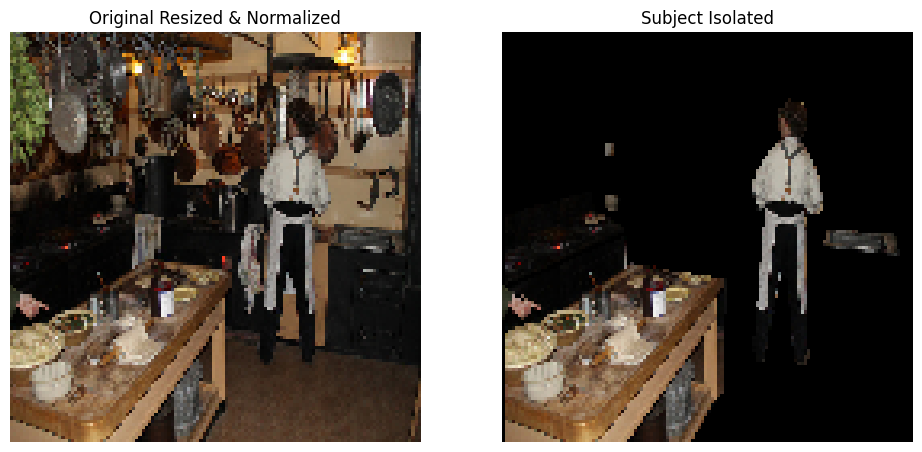

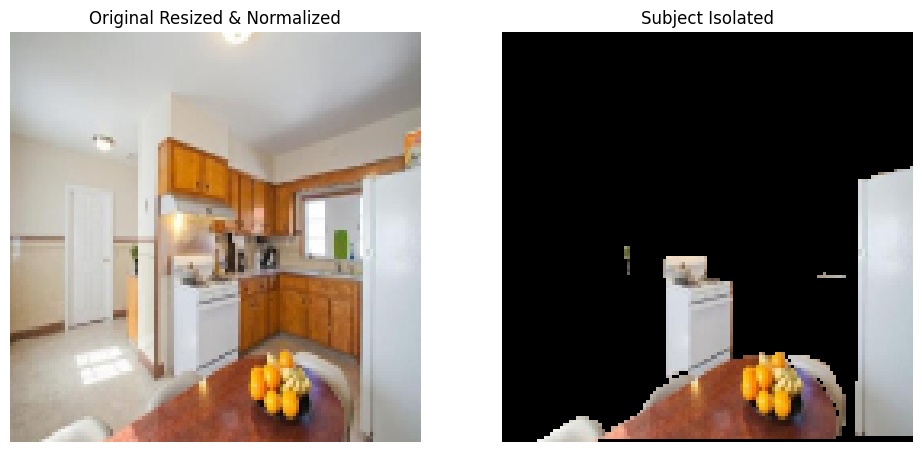

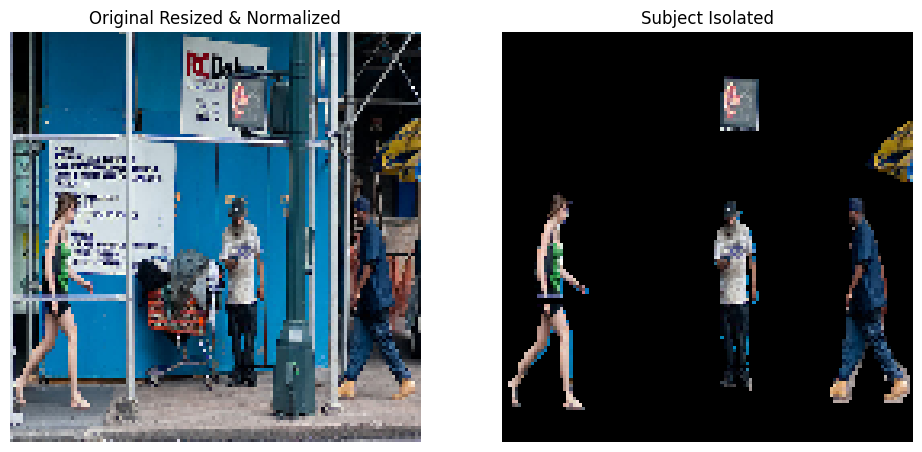

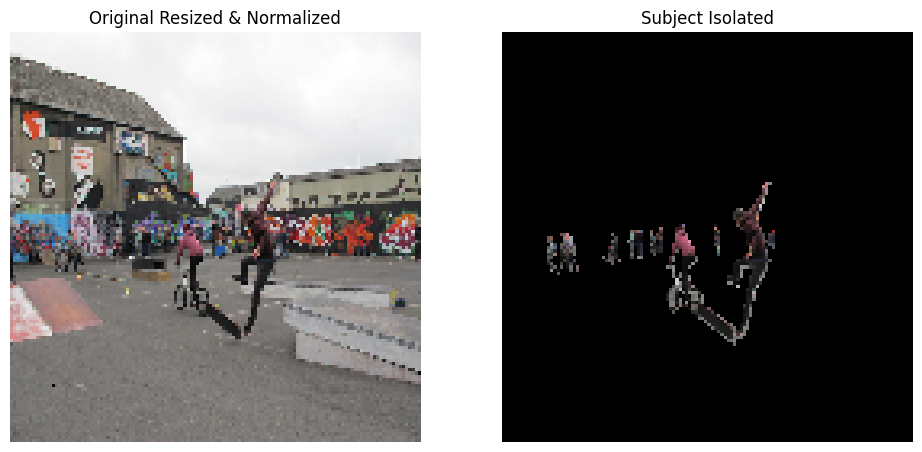

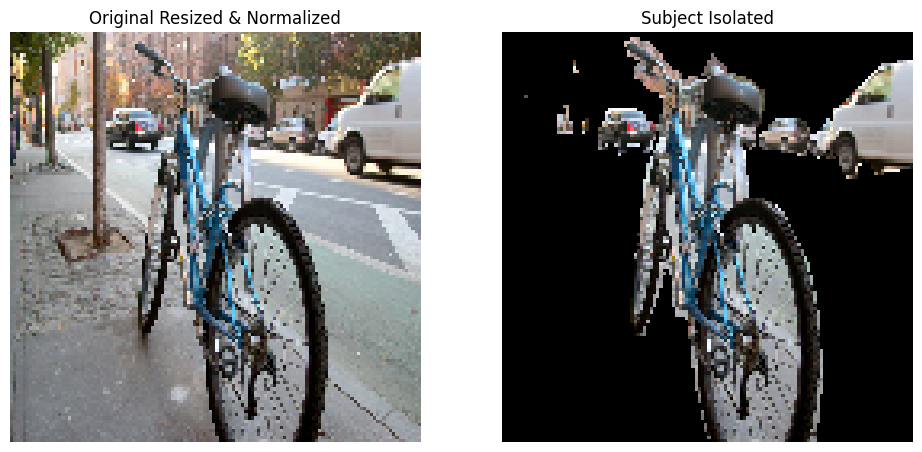

In [ ]:
# ==============================
# WEEK 2: PREPROCESSING PIPELINE (Corrected Augmentation)
# ==============================

# Step 1: Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pycocotools.coco import COCO
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# Step 2: Set Dataset Paths
# ==============================
DATA_ROOT = "/content/drive/MyDrive/VisionAI"  # Update your path
IMAGES_DIR = os.path.join(DATA_ROOT, "val2017")  # or train2017
ANN_FILE = os.path.join(DATA_ROOT, "annotations", "instances_val2017.json")

coco = COCO(ANN_FILE)
img_ids = coco.getImgIds()
print("Total images:", len(img_ids))

# ==============================
# Step 3: Function - Build Binary Mask
# ==============================
def build_binary_mask(coco, img_info):
    ann_ids = coco.getAnnIds(imgIds=img_info['id'], iscrowd=False)
    anns = coco.loadAnns(ann_ids)
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))
    return np.clip(mask, 0, 1)

# ==============================
# Step 4: Function - Preprocess Image & Mask
# ==============================
def preprocess_image_and_mask(img, mask, target_size=(128,128)):
    img = cv2.resize(img, target_size)
    mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
    img = img / 255.0
    mask = (mask > 0).astype(np.uint8)
    return img, mask

# ==============================
# Step 5: Function - Subject Isolation
# ==============================
def isolate_subject(img, mask):
    mask_3c = np.stack([mask]*3, axis=-1)
    return img * mask_3c

# ==============================
# Step 6: Data Augmentation Setup
# ==============================
data_gen_args = dict(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=15,
    brightness_range=[0.8, 1.2]
)
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen  = ImageDataGenerator(**data_gen_args)

# ==============================
# Step 7: Pipeline Execution - First 5 Images
# ==============================
num_samples = 5
for img_id in img_ids[:num_samples]:

    # 1 Load image
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGES_DIR, img_info['file_name'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2 Build binary mask (multi-class to binary)
    mask = build_binary_mask(coco, img_info)

    # 3 Preprocess image & mask (resize, normalize, alignment)
    img_proc, mask_proc = preprocess_image_and_mask(img, mask)

    # 4 Subject isolation
    isolated_img = isolate_subject(img_proc, mask_proc)

    # 5 Apply augmentation (1 augmented version)
    img_aug = img_proc[np.newaxis,...]
    mask_aug = mask_proc[np.newaxis,...,np.newaxis]

    aug_iter = zip(
        image_datagen.flow(img_aug, batch_size=1, seed=42),
        mask_datagen.flow(mask_aug, batch_size=1, seed=42)
    )

    img_augmented, mask_augmented = next(aug_iter)

    # ✅ Corrected mask: threshold to keep binary after augmentation
    mask_augmented_bin = (mask_augmented[0,:,:,0] > 0.5).astype(np.uint8)

    # Subject isolation for augmented image
    isolated_aug = isolate_subject(img_augmented[0], mask_augmented_bin)

    # 6️⃣ Display results
    plt.figure(figsize=(18,6))

    plt.subplot(1,3,1)
    plt.imshow(img_proc)
    plt.title("Original Resized & Normalized")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(isolated_img)
    plt.title("Subject Isolated")
    plt.axis("off")


    plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


loading annotations into memory...
Done (t=0.73s)
creating index...
index created!
Main subject: person | Category ID: 1


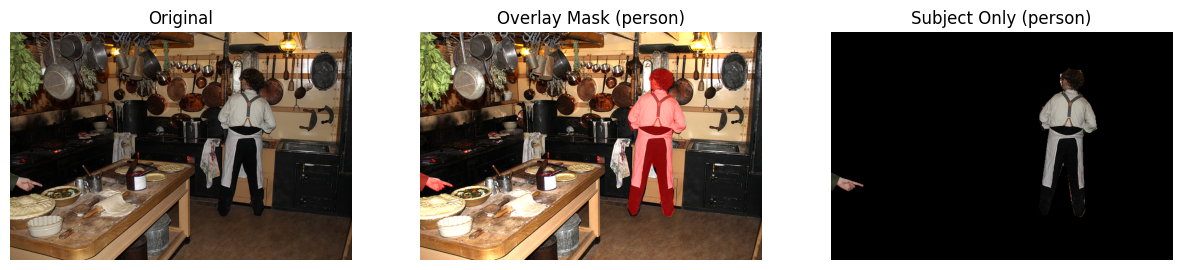

 No 'person' found in image: 000000037777.jpg


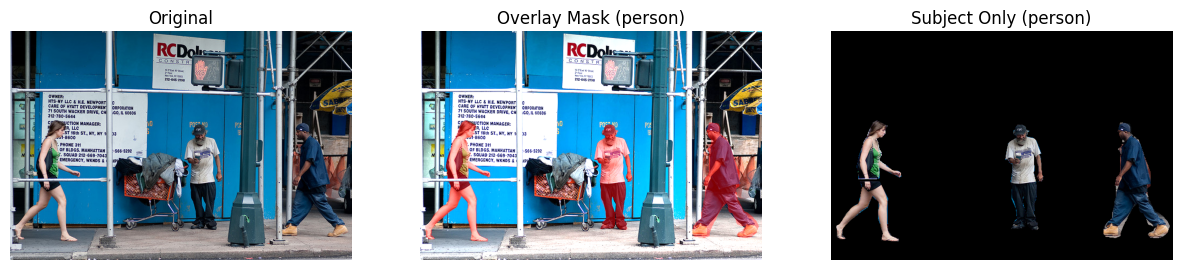

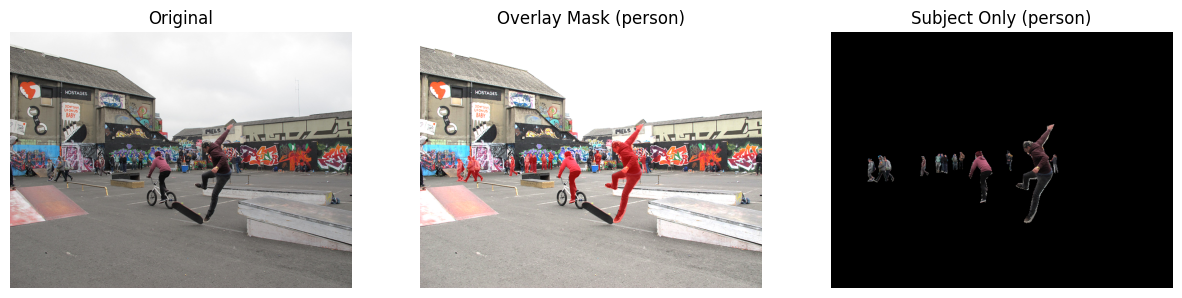

 No 'person' found in image: 000000174482.jpg


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# ==== STEP 1: Setup Paths ====
ANN_FILE = "/content/drive/MyDrive/VisionAI/annotations/instances_val2017.json"
IMAGES_DIR = "/content/drive/MyDrive/VisionAI/val2017"
coco = COCO(ANN_FILE)

# ==== STEP 2: Pick main subject ====
main_subject_name = "person"   # change to 'dog', 'car', etc.
main_subject_cat_id = coco.getCatIds(catNms=[main_subject_name])[0]
print("Main subject:", main_subject_name, "| Category ID:", main_subject_cat_id)

# ==== STEP 3: Build binary mask for the chosen subject ====
def build_binary_mask_main_subject(coco, img_info, main_category_name="person"):
    cat_ids = coco.getCatIds(catNms=[main_category_name])
    ann_ids = coco.getAnnIds(imgIds=img_info['id'], catIds=cat_ids, iscrowd=False)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    return (mask > 0).astype(np.uint8)

# ==== STEP 4: Process multiple images ====
img_ids = coco.getImgIds()[:5]  # first 5 images

for img_id in img_ids:
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(IMAGES_DIR, img_info['file_name'])

    # Check image exists
    if not os.path.exists(img_path):
        print(f" Image not found: {img_path}")
        continue

    # Load image
    image = cv2.imread(img_path)
    if image is None:
        print(f" Failed to load image: {img_path}")
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Build mask
    mask = build_binary_mask_main_subject(coco, img_info, main_category_name=main_subject_name)

    # Check mask is not empty
    if mask.sum() == 0:
        print(f" No '{main_subject_name}' found in image: {img_info['file_name']}")
        continue

    # 1. Overlay mask (red transparent)
    overlay = image.copy()
    overlay[mask == 1] = [255, 0, 0]
    alpha = 0.5
    overlayed = cv2.addWeighted(image, 1, overlay, alpha, 0)

    # 2. Subject only (keep original color, background black)
    subject_only = image.copy()
    subject_only[mask == 0] = 0

    # ==== Display Results ====
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(overlayed)
    plt.title(f"Overlay Mask ({main_subject_name})")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(subject_only)
    plt.title(f"Subject Only ({main_subject_name})")
    plt.axis("off")

    plt.show()


loading annotations into memory...
Done (t=2.88s)
creating index...
index created!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Epoch 1/5, Train Loss: 0.3542, Val Loss: 0.2402
Epoch 2/5, Train Loss: 0.2524, Val Loss: 0.2211
Epoch 3/5, Train Loss: 0.2211, Val Loss: 0.2166
Epoch 4/5, Train Loss: 0.2022, Val Loss: 0.2217
Epoch 5/5, Train Loss: 0.1888, Val Loss: 0.2124


Mean IoU: 0.6638, Mean Dice: 0.7882, Pixel Acc: 0.8694


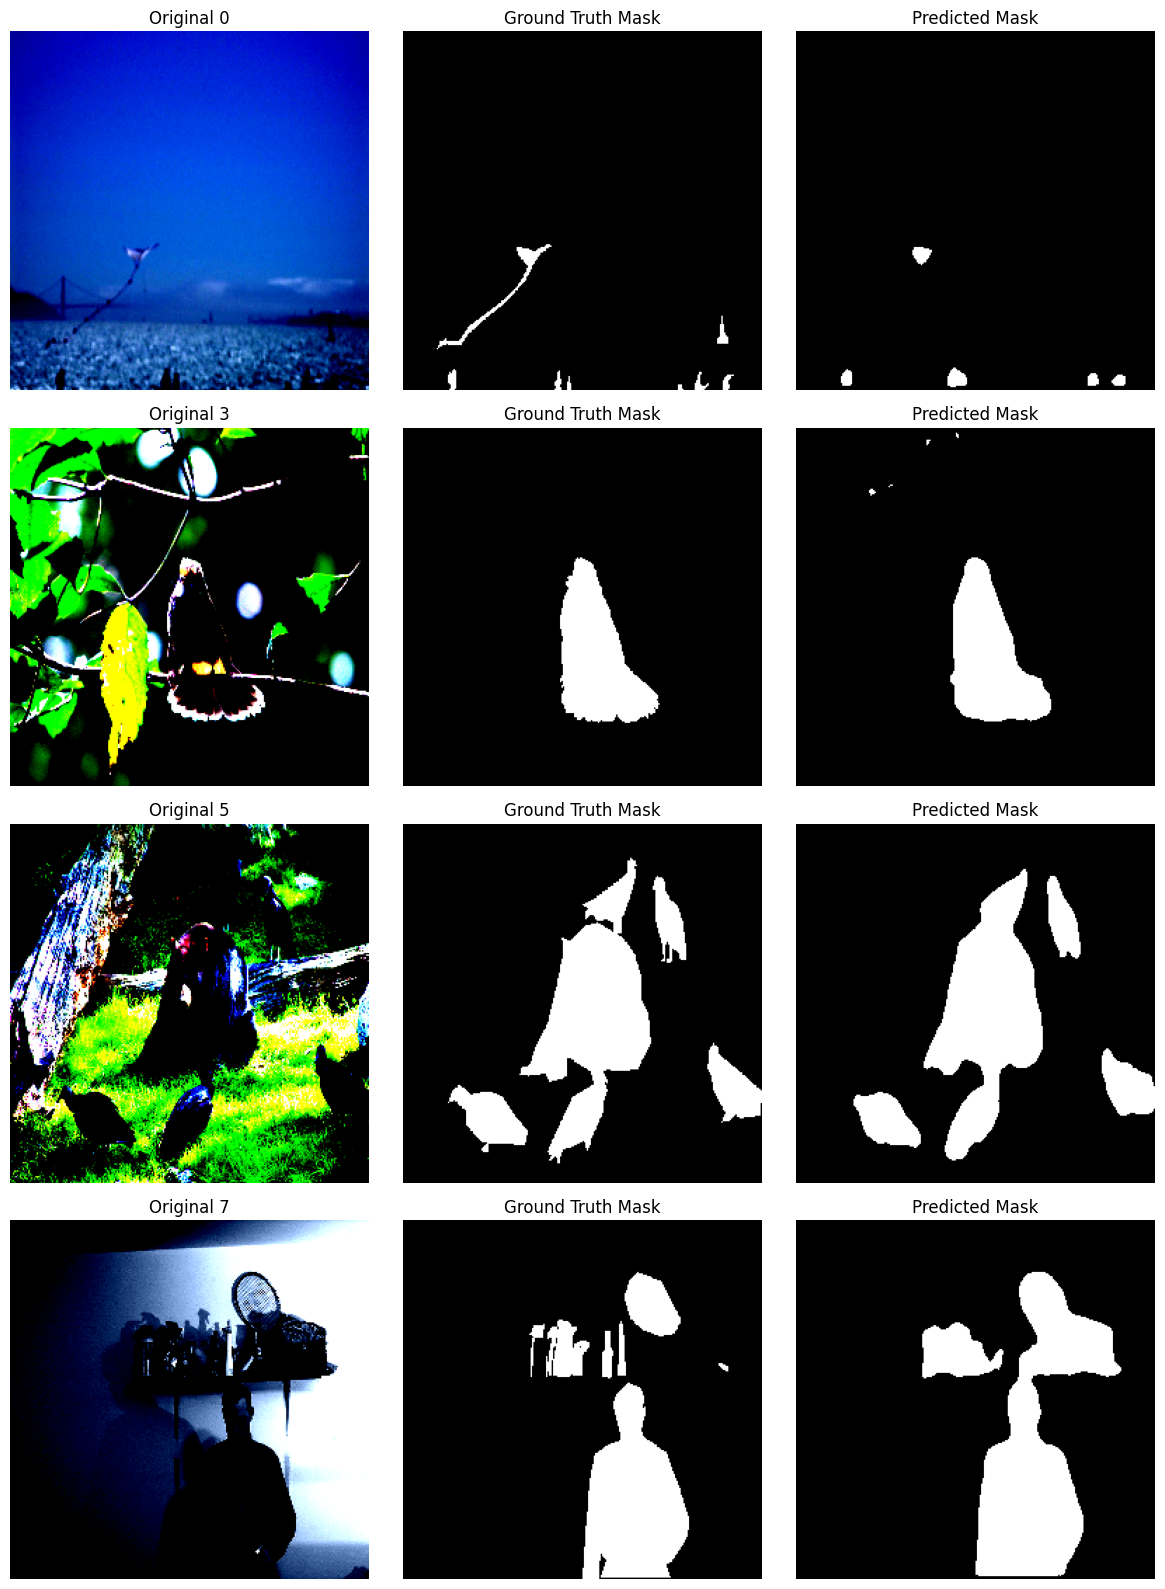

In [ ]:
# -------------------- WEEK 3 --U-Net with a pretrained EfficientNet-B4 --------------------
!pip install -q segmentation-models-pytorch
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

# -------------------- Paths --------------------
coco_img_dir = "/content/drive/MyDrive/VisionAI/val2017"   # path to COCO val images
coco_ann_file = "/content/drive/MyDrive/VisionAI/annotations/instances_val2017.json"  # annotations

# -------------------- Dataset --------------------
class COCOSegDataset(Dataset):
    def __init__(self, img_dir, ann_file, transform=None):
        self.coco = COCO(ann_file)
        self.img_dir = img_dir
        self.ids = list(self.coco.imgs.keys())
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.img_dir, img_info['file_name'])
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float()

        return image, mask

# -------------------- Transformations --------------------
train_tf = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2(),
])
val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2(),
])

# -------------------- Train / Val Split --------------------
dataset = COCOSegDataset(coco_img_dir, coco_ann_file, transform=train_tf)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

# -------------------- Model --------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = smp.Unet(
    encoder_name="efficientnet-b4",    # BEST pretrained backbone
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(DEVICE)

loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -------------------- Training --------------------
def train_model(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

train_model(model, train_loader, val_loader, epochs=5)

# -------------------- Metrics --------------------
def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

def dice_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def pixel_accuracy(pred, target):
    pred = (pred > 0.5).float()
    correct = (pred == target).float().sum()
    total = torch.numel(pred)
    return correct / total

# Evaluate on validation set
model.eval()
ious, dices, accs = [], [], []
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs = torch.sigmoid(model(images))
        ious.append(iou_score(outputs, masks).item())
        dices.append(dice_score(outputs, masks).item())
        accs.append(pixel_accuracy(outputs, masks).item())
print(f"Mean IoU: {np.mean(ious):.4f}, Mean Dice: {np.mean(dices):.4f}, Pixel Acc: {np.mean(accs):.4f}")


# -------------------- Multi-sample Visualization --------------------
def visualize_predictions(model, dataset, indices=[0, 5, 10, 15]):
    model.eval()
    plt.figure(figsize=(12, len(indices) * 4))  # expand figure size for multiple rows

    for row, idx in enumerate(indices):
        image, mask = dataset[idx]
        image_input = image.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = torch.sigmoid(model(image_input)).squeeze().cpu().numpy()

        img_np = image.squeeze().cpu().permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().cpu().numpy()
        pred_mask = (pred > 0.5).astype(np.uint8)

        # Original
        plt.subplot(len(indices), 3, row * 3 + 1)
        plt.imshow(img_np)
        plt.title(f"Original {idx}")
        plt.axis("off")

        # Ground Truth
        plt.subplot(len(indices), 3, row * 3 + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Prediction
        plt.subplot(len(indices), 3, row * 3 + 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Show 4 validation samples (you can change indices list)
visualize_predictions(model, val_dataset, indices=[0, 3, 5, 7])


loading annotations into memory...
Done (t=0.96s)
creating index...
index created!
Epoch 1/20, Train Loss: 0.3294, Val Loss: 0.2307
Epoch 2/20, Train Loss: 0.2522, Val Loss: 0.2164
Epoch 3/20, Train Loss: 0.2233, Val Loss: 0.2084
Epoch 4/20, Train Loss: 0.2037, Val Loss: 0.2019
Epoch 5/20, Train Loss: 0.1879, Val Loss: 0.1950
Epoch 6/20, Train Loss: 0.1796, Val Loss: 0.1969
Epoch 7/20, Train Loss: 0.1703, Val Loss: 0.1936
Epoch 8/20, Train Loss: 0.1660, Val Loss: 0.1945
Epoch 9/20, Train Loss: 0.1596, Val Loss: 0.1911
Epoch 10/20, Train Loss: 0.1526, Val Loss: 0.1916
Epoch 11/20, Train Loss: 0.1458, Val Loss: 0.1882
Epoch 12/20, Train Loss: 0.1423, Val Loss: 0.1934
Epoch 13/20, Train Loss: 0.1368, Val Loss: 0.1949
Epoch 14/20, Train Loss: 0.1328, Val Loss: 0.1960
Epoch 15/20, Train Loss: 0.1310, Val Loss: 0.1933
Epoch 16/20, Train Loss: 0.1268, Val Loss: 0.1929
Epoch 17/20, Train Loss: 0.1225, Val Loss: 0.1860
Epoch 18/20, Train Loss: 0.1196, Val Loss: 0.1966
Epoch 19/20, Train Loss: 0

Mean IoU: 0.6893, Mean Dice: 0.8061, Pixel Acc: 0.8846


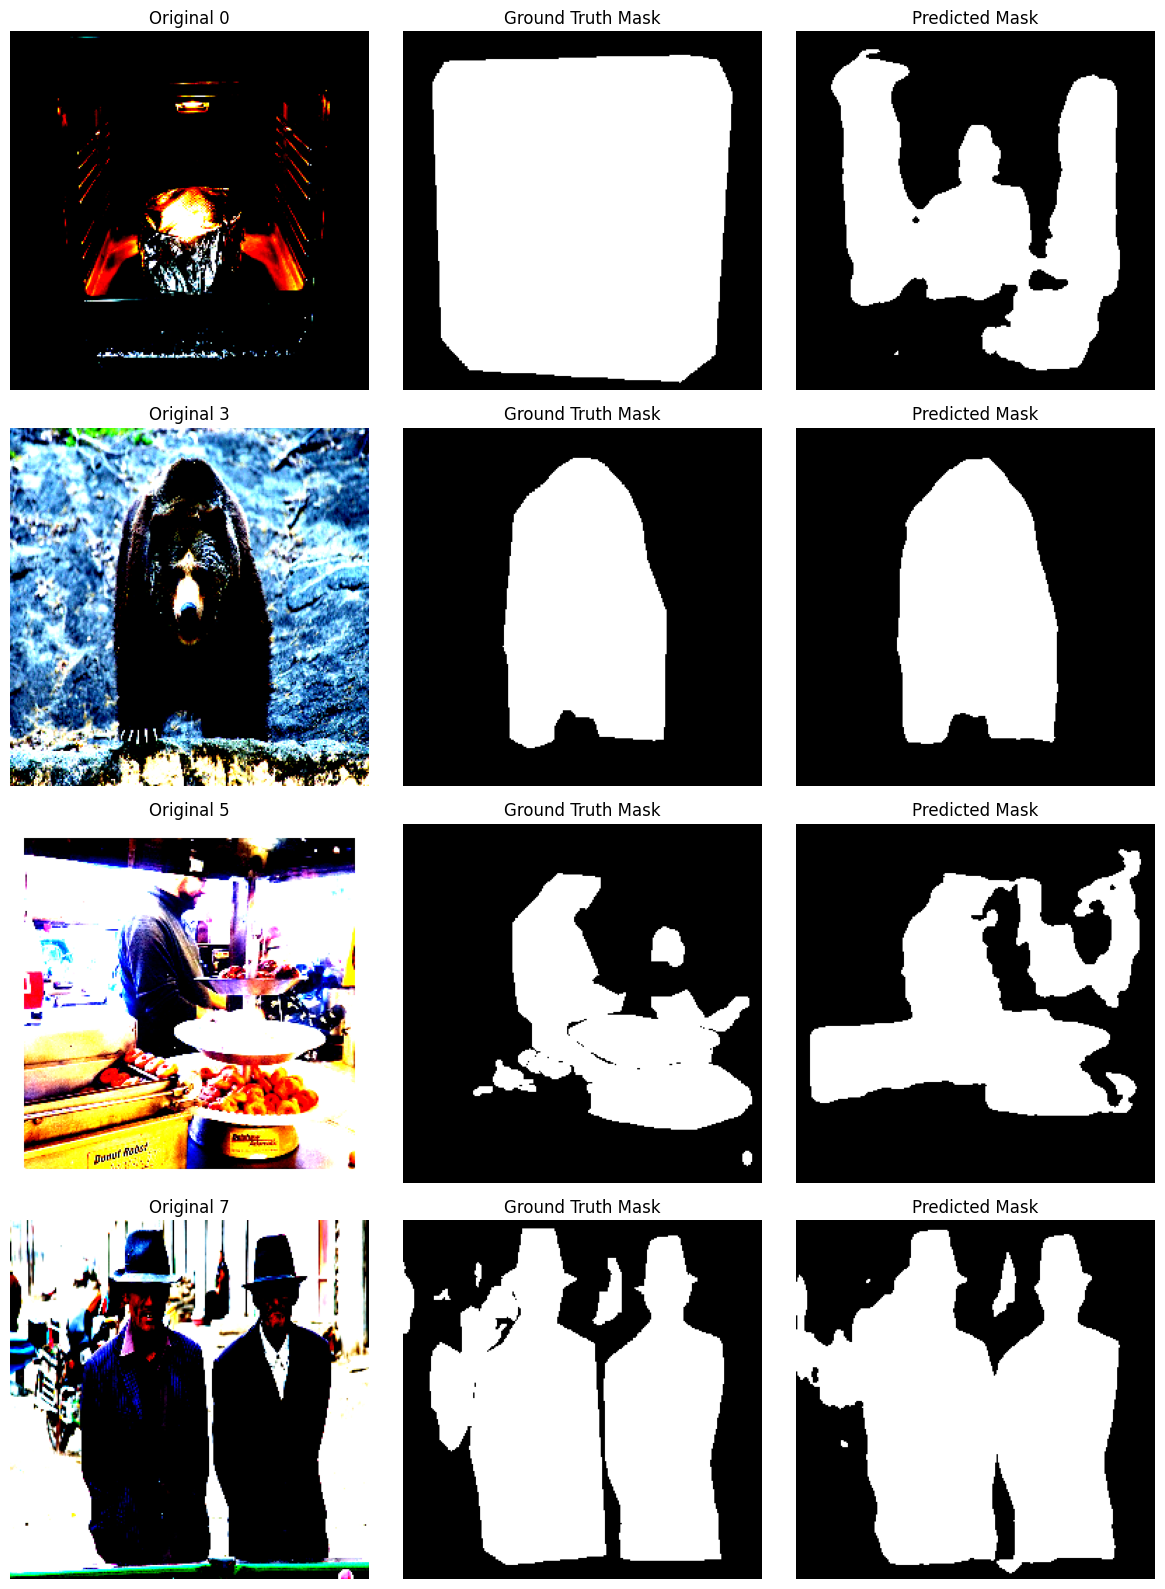

In [ ]:
# -------------------- WEEK 3 --U-Net with a pretrained EfficientNet-B4 --------------------
!pip install -q segmentation-models-pytorch
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

# -------------------- Paths --------------------
coco_img_dir = "/content/drive/MyDrive/VisionAI/val2017"   # path to COCO val images
coco_ann_file = "/content/drive/MyDrive/VisionAI/annotations/instances_val2017.json"  # annotations

# -------------------- Dataset --------------------
class COCOSegDataset(Dataset):
    def __init__(self, img_dir, ann_file, transform=None):
        self.coco = COCO(ann_file)
        self.img_dir = img_dir
        self.ids = list(self.coco.imgs.keys())
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.img_dir, img_info['file_name'])
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float()

        return image, mask

# -------------------- Transformations --------------------
train_tf = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2(),
])
val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2(),
])

# -------------------- Train / Val Split --------------------
dataset = COCOSegDataset(coco_img_dir, coco_ann_file, transform=train_tf)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

# -------------------- Model --------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = smp.Unet(
    encoder_name="efficientnet-b4",    # BEST pretrained backbone
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(DEVICE)

loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -------------------- Training --------------------
def train_model(model, train_loader, val_loader, epochs=20):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

train_model(model, train_loader, val_loader, epochs=20)

# -------------------- Metrics --------------------
def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

def dice_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def pixel_accuracy(pred, target):
    pred = (pred > 0.5).float()
    correct = (pred == target).float().sum()
    total = torch.numel(pred)
    return correct / total

# Evaluate on validation set
model.eval()
ious, dices, accs = [], [], []
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs = torch.sigmoid(model(images))
        ious.append(iou_score(outputs, masks).item())
        dices.append(dice_score(outputs, masks).item())
        accs.append(pixel_accuracy(outputs, masks).item())
print(f"Mean IoU: {np.mean(ious):.4f}, Mean Dice: {np.mean(dices):.4f}, Pixel Acc: {np.mean(accs):.4f}")


# -------------------- Multi-sample Visualization --------------------
def visualize_predictions(model, dataset, indices=[0, 5, 10, 15]):
    model.eval()
    plt.figure(figsize=(12, len(indices) * 4))  # expand figure size for multiple rows

    for row, idx in enumerate(indices):
        image, mask = dataset[idx]
        image_input = image.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = torch.sigmoid(model(image_input)).squeeze().cpu().numpy()

        img_np = image.squeeze().cpu().permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().cpu().numpy()
        pred_mask = (pred > 0.5).astype(np.uint8)

        # Original
        plt.subplot(len(indices), 3, row * 3 + 1)
        plt.imshow(img_np)
        plt.title(f"Original {idx}")
        plt.axis("off")

        # Ground Truth
        plt.subplot(len(indices), 3, row * 3 + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Prediction
        plt.subplot(len(indices), 3, row * 3 + 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Show 4 validation samples (you can change indices list)
visualize_predictions(model, val_dataset, indices=[0, 3, 5, 7])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


loading annotations into memory...
Done (t=4.23s)
creating index...
index created!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

Epoch 1/20, Train Loss: 0.3624, Val Loss: 0.2590
Epoch 2/20, Train Loss: 0.2584, Val Loss: 0.2310
Epoch 3/20, Train Loss: 0.2305, Val Loss: 0.2188
Epoch 4/20, Train Loss: 0.2171, Val Loss: 0.2166
Epoch 5/20, Train Loss: 0.2032, Val Loss: 0.2163
Epoch 6/20, Train Loss: 0.1987, Val Loss: 0.2194
Epoch 7/20, Train Loss: 0.1916, Val Loss: 0.2184
Epoch 8/20, Train Loss: 0.1797, Val Loss: 0.2233
Epoch 9/20, Train Loss: 0.1754, Val Loss: 0.2189
Epoch 10/20, Train Loss: 0.1692, Val Loss: 0.2245
Epoch 11/20, Train Loss: 0.1644, Val Loss: 0.2167
Epoch 12/20, Train Loss: 0.1623, Val Loss: 0.2207
Epoch 13/20, Train Loss: 0.1581, Val Loss: 0.2213
Epoch 14/20, Train Loss: 0.1538, Val Loss: 0.2129
Epoch 15/20, Train Loss: 0.1503, Val Loss: 0.2153
Epoch 16/20, Train Loss: 0.1481, Val Loss: 0.2172
Epoch 17/20, Train Loss: 0.1502, Val Loss: 0.2145
Epoch 18/20, Train Loss: 0.1448, Val Loss: 0.2092
Epoch 19/20, Train Loss: 0.1410, Val Loss: 0.2197
Epoch 20/20, Train Loss: 0.1408, Val Loss: 0.2189


Mean IoU: 0.6546, Mean Dice: 0.7811, Pixel Acc: 0.8632


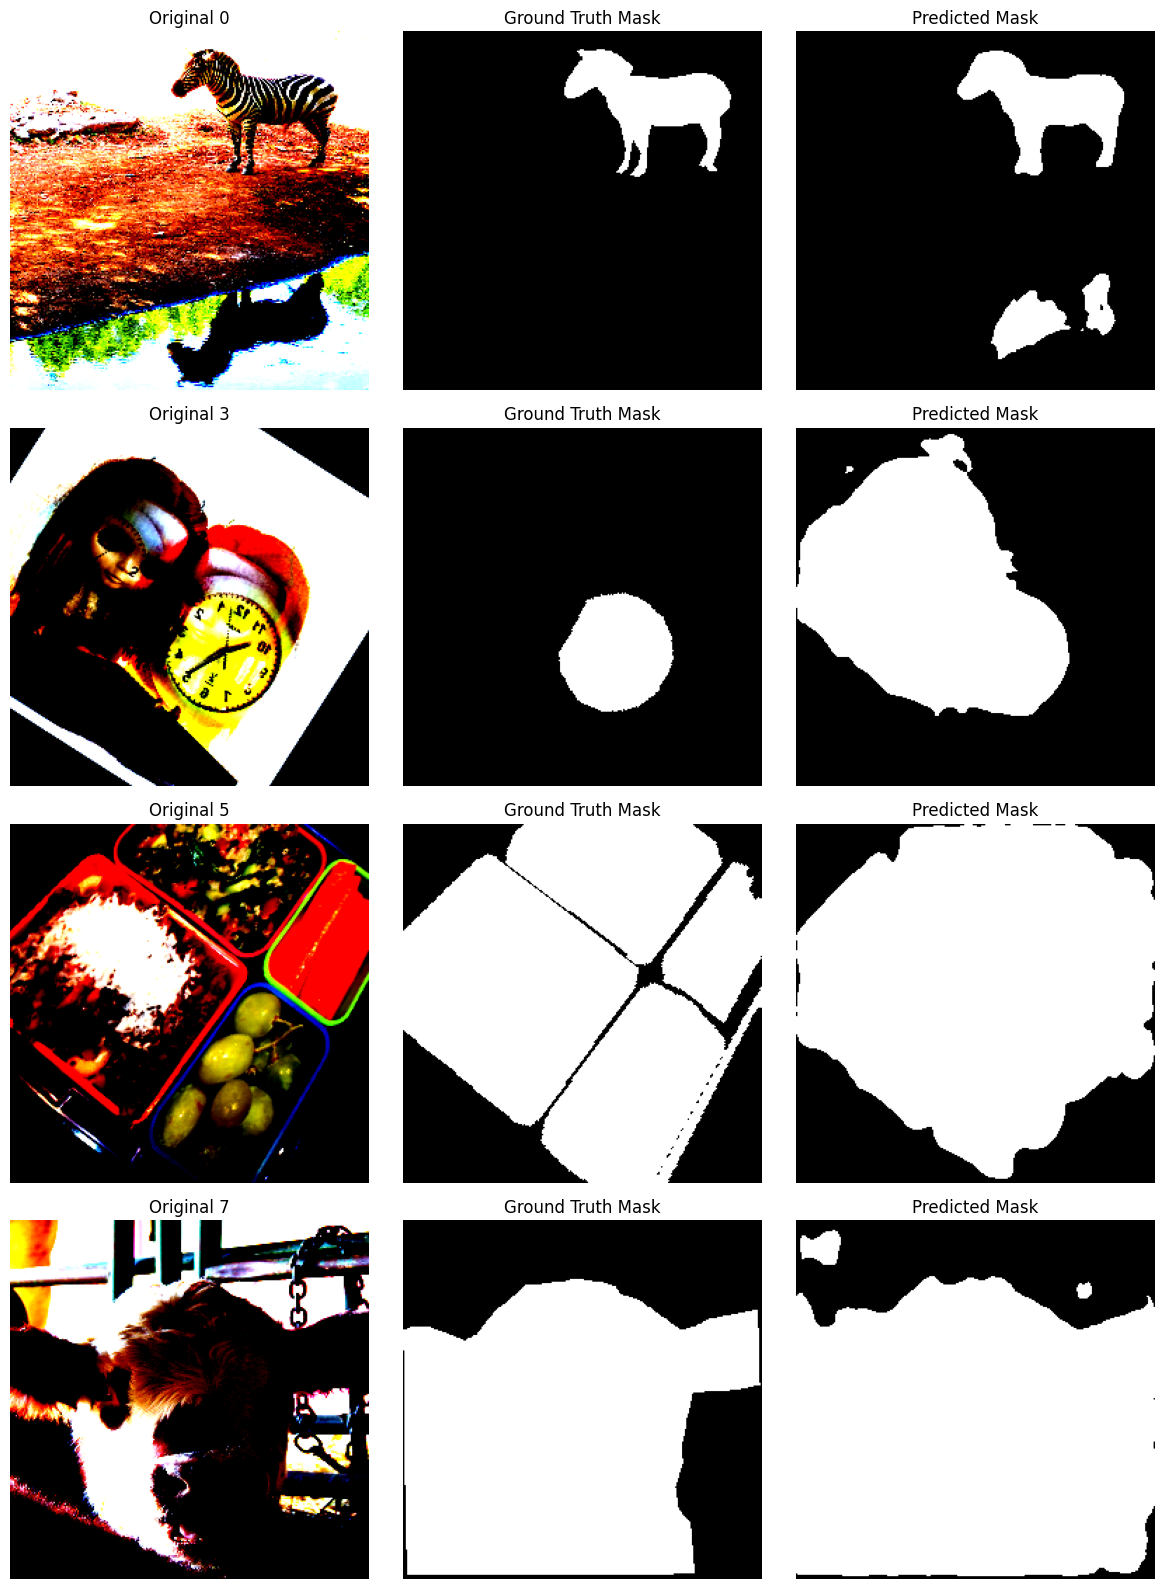

In [ ]:
# -------------------- WEEK 4: Fine-tuning with EfficientNet-B5 --------------------
!pip install -q segmentation-models-pytorch albumentations

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -------------------- Paths --------------------
coco_img_dir = "/content/drive/MyDrive/VisionAI/val2017"   # update path if needed
coco_ann_file = "/content/drive/MyDrive/VisionAI/annotations/instances_val2017.json"

# -------------------- Dataset --------------------
class COCOSegDataset(Dataset):
    def __init__(self, img_dir, ann_file, transform=None):
        self.coco = COCO(ann_file)
        self.img_dir = img_dir
        self.ids = list(self.coco.imgs.keys())
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.img_dir, img_info['file_name'])
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float()

        return image, mask

# -------------------- Augmentations --------------------
train_tf = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(p=0.3),
    A.Normalize(),
    ToTensorV2(),
])
val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2(),
])

# -------------------- Train / Val Split --------------------
dataset = COCOSegDataset(coco_img_dir, coco_ann_file, transform=train_tf)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

# -------------------- Model --------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Base model with EfficientNet-B5
base_model = smp.Unet(
    encoder_name="efficientnet-b5",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

# Add an extra convolutional layer at the end
class CustomUNet(nn.Module):
    def __init__(self, base_model):
        super(CustomUNet, self).__init__()
        self.base = base_model
        self.extra_conv = nn.Conv2d(1, 1, kernel_size=3, padding=1)  # new layer

    def forward(self, x):
        x = self.base(x)
        x = self.extra_conv(x)
        return x

model = CustomUNet(base_model).to(DEVICE)

# Loss + Optimizer
loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -------------------- Training --------------------
def train_model(model, train_loader, val_loader, epochs=20):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Val Loss: {val_loss/len(val_loader):.4f}")

train_model(model, train_loader, val_loader, epochs=20)

# -------------------- Metrics --------------------
def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

def dice_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def pixel_accuracy(pred, target):
    pred = (pred > 0.5).float()
    correct = (pred == target).float().sum()
    total = torch.numel(pred)
    return correct / total

# Evaluate
model.eval()
ious, dices, accs = [], [], []
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs = torch.sigmoid(model(images))
        ious.append(iou_score(outputs, masks).item())
        dices.append(dice_score(outputs, masks).item())
        accs.append(pixel_accuracy(outputs, masks).item())
print(f"Mean IoU: {np.mean(ious):.4f}, Mean Dice: {np.mean(dices):.4f}, Pixel Acc: {np.mean(accs):.4f}")

# -------------------- Visualization --------------------
def visualize_predictions(model, dataset, indices=[0, 3, 5, 7]):
    model.eval()
    plt.figure(figsize=(12, len(indices) * 4))
    for row, idx in enumerate(indices):
        image, mask = dataset[idx]
        image_input = image.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = torch.sigmoid(model(image_input)).squeeze().cpu().numpy()

        img_np = image.squeeze().cpu().permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().cpu().numpy()
        pred_mask = (pred > 0.5).astype(np.uint8)

        # Original
        plt.subplot(len(indices), 3, row * 3 + 1)
        plt.imshow(img_np)
        plt.title(f"Original {idx}")
        plt.axis("off")

        # Ground Truth
        plt.subplot(len(indices), 3, row * 3 + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth Mask")
        plt.axis("off")

        # Prediction
        plt.subplot(len(indices), 3, row * 3 + 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Show predictions
visualize_predictions(model, val_dataset, indices=[0, 3, 5, 7])


In [ ]:
save_path = "/content/drive/MyDrive/VisionAI/week4_model.pth"
torch.save(model.state_dict(), save_path)
print(f"✅ Model saved at {save_path}")


✅ Model saved at /content/drive/MyDrive/VisionAI/week4_model.pth


loading annotations into memory...
Done (t=0.51s)
creating index...
index created!


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

Epoch 1/15, Train Loss: 0.3836, Val Loss: 0.3260
Epoch 2/15, Train Loss: 0.3475, Val Loss: 0.3122
Epoch 3/15, Train Loss: 0.3336, Val Loss: 0.3243
Epoch 4/15, Train Loss: 0.3269, Val Loss: 0.3169
Epoch 5/15, Train Loss: 0.3256, Val Loss: 0.2930
Epoch 6/15, Train Loss: 0.3186, Val Loss: 0.3174
Epoch 7/15, Train Loss: 0.3229, Val Loss: 0.3004
Epoch 8/15, Train Loss: 0.3077, Val Loss: 0.2920
Epoch 9/15, Train Loss: 0.3046, Val Loss: 0.3095
Epoch 10/15, Train Loss: 0.3058, Val Loss: 0.2898
Epoch 11/15, Train Loss: 0.2957, Val Loss: 0.2934
Epoch 12/15, Train Loss: 0.3019, Val Loss: 0.2918
Epoch 13/15, Train Loss: 0.3004, Val Loss: 0.3051
Epoch 14/15, Train Loss: 0.2936, Val Loss: 0.2866


Epoch 15/15, Train Loss: 0.2886, Val Loss: 0.2800


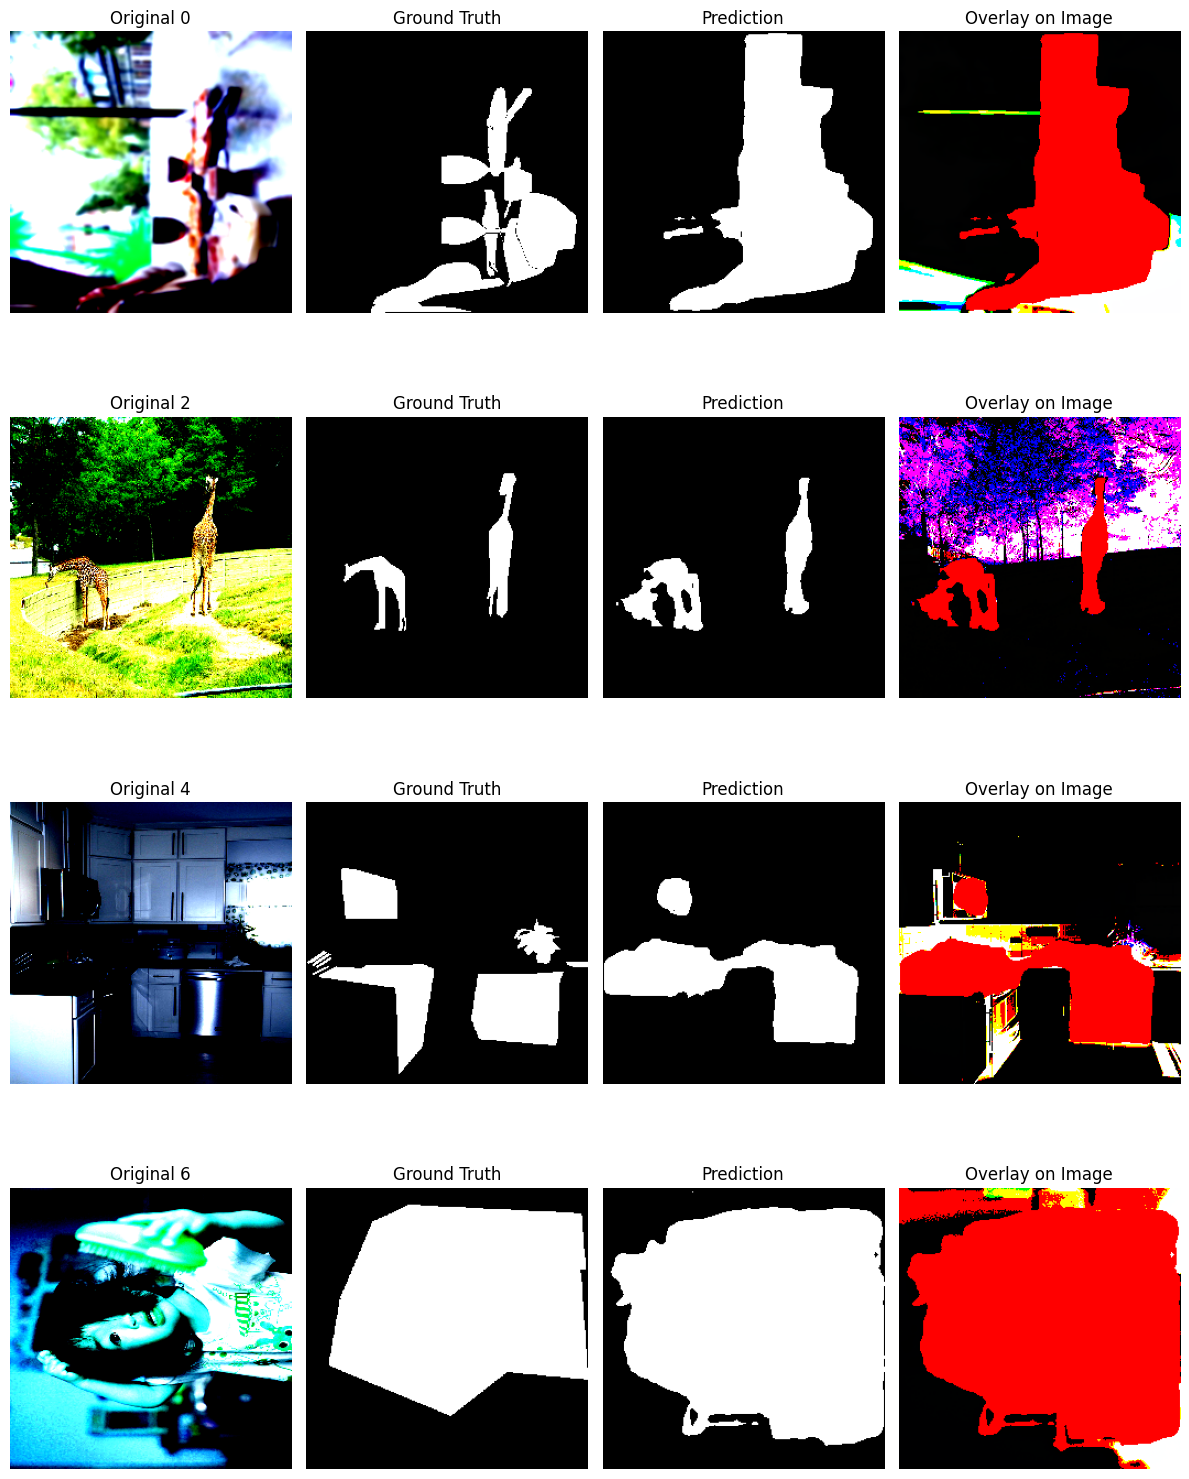

In [ ]:
# -------------------- WEEK 5: Improved Data + Architectures --------------------
!pip install -q segmentation-models-pytorch
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# -------------------- Paths --------------------
coco_img_dir = "/content/drive/MyDrive/VisionAI/val2017"
coco_ann_file = "/content/drive/MyDrive/VisionAI/annotations/instances_val2017.json"

# -------------------- Dataset --------------------
class COCOSegDataset(Dataset):
    def __init__(self, img_dir, ann_file, transform=None):
        self.coco = COCO(ann_file)
        self.img_dir = img_dir
        self.ids = list(self.coco.imgs.keys())
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        path = os.path.join(self.img_dir, img_info['file_name'])
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float()

        return image, mask

# -------------------- Advanced Transformations --------------------
train_tf = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ColorJitter(p=0.3),
    A.GaussianBlur(p=0.2),
    A.Normalize(),
    ToTensorV2(),
])
val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2(),
])

# -------------------- Train / Val Split --------------------
dataset = COCOSegDataset(coco_img_dir, coco_ann_file, transform=train_tf)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

# -------------------- Model (DeepLabV3+ with ResNet101 backbone) --------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = smp.DeepLabV3Plus(
    encoder_name="resnet101",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(DEVICE)

loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# -------------------- Training --------------------
def train_model(model, train_loader, val_loader, epochs=15):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")

# Train model
train_model(model, train_loader, val_loader, epochs=15)

# -------------------- Visualization (with overlay) --------------------
def visualize_predictions(model, dataset, indices=[0, 3, 5, 7]):
    model.eval()
    plt.figure(figsize=(12, len(indices) * 4))

    for row, idx in enumerate(indices):
        image, mask = dataset[idx]
        image_input = image.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = torch.sigmoid(model(image_input)).squeeze().cpu().numpy()

        img_np = image.permute(1, 2, 0).cpu().numpy()
        mask_np = mask.squeeze().cpu().numpy()
        pred_mask = (pred > 0.5).astype(np.uint8)

        # Original
        plt.subplot(len(indices), 4, row * 4 + 1)
        plt.imshow(img_np)
        plt.title(f"Original {idx}")
        plt.axis("off")

        # Ground Truth
        plt.subplot(len(indices), 4, row * 4 + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        # Prediction (mask only)
        plt.subplot(len(indices), 4, row * 4 + 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

        # Overlay prediction on color image
        overlay = img_np.copy()
        overlay[pred_mask == 1] = [255, 0, 0]  # red overlay
        plt.subplot(len(indices), 4, row * 4 + 4)
        plt.imshow(overlay.astype(np.uint8))
        plt.title("Overlay on Image")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Show predictions with color overlays
visualize_predictions(model, val_dataset, indices=[0, 2, 4, 6])


Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Training Epoch 1: 100%|██████████| 1250/1250 [05:14<00:00,  3.97it/s]


Epoch [1/5] Loss: 0.9532


Training Epoch 2: 100%|██████████| 1250/1250 [05:19<00:00,  3.92it/s]


Epoch [2/5] Loss: 0.8393


...

Training Epoch 4: 100%|██████████| 1250/1250 [05:19<00:00,  3.91it/s]


Epoch [4/5] Loss: 0.7713


Training Epoch 5: 100%|██████████| 1250/1250 [05:26<00:00,  3.83it/s]

Epoch [5/5] Loss: 0.7527


Mean IoU: nan
Mean Dice: nan


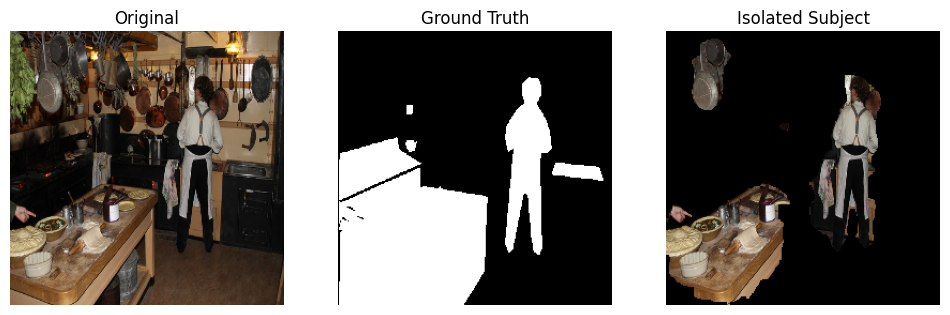

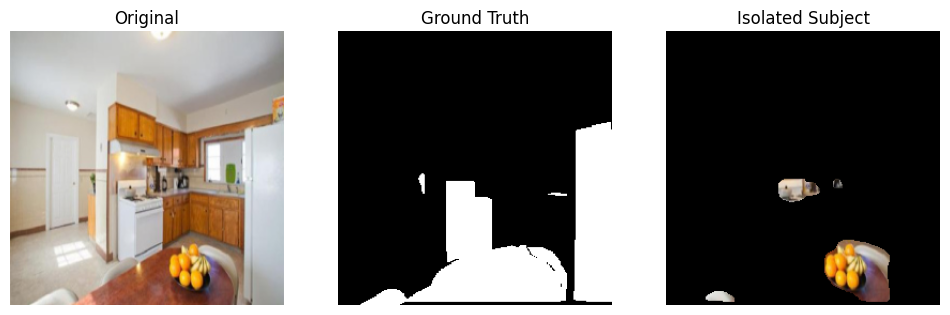

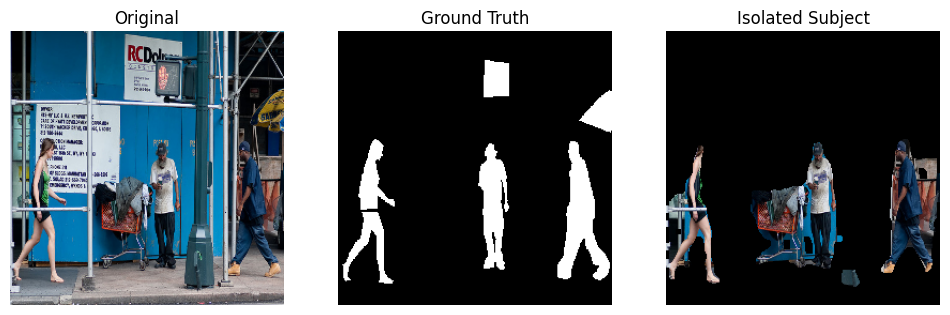

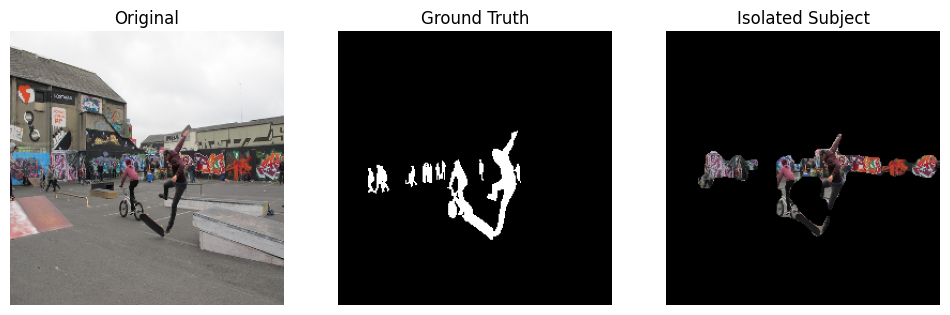

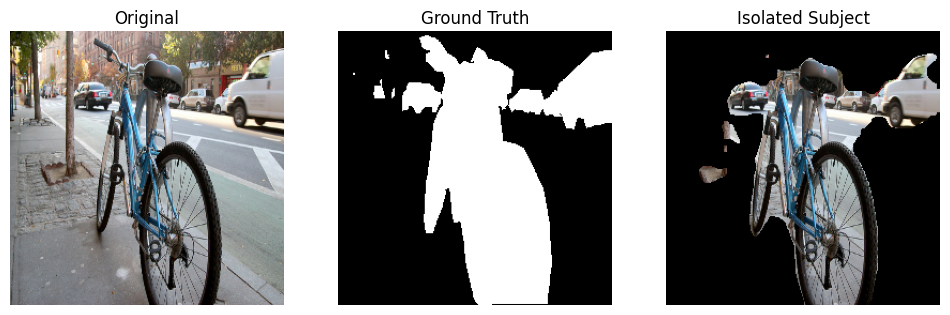

In [ ]:
# -------------------- WEEK 5 SETUP --------------------
!pip install -q albumentations tqdm
!pip install -q torch torchvision segmentation-models-pytorch

import os
import json
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
import segmentation_models_pytorch as smp
from skimage.draw import polygon

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------- HYPERPARAMS --------------------
image_size = 256
batch_size = 4
num_epochs = 5
lr = 1e-4

# -------------------- DATASET --------------------
class CocoBinaryDataset(Dataset):
    def __init__(self, images_path, annotations_path, transform=None):
        self.images_path = images_path
        self.transform = transform
        with open(annotations_path, "r") as f:
            coco = json.load(f)

        self.images = {img["id"]: img["file_name"] for img in coco["images"]}
        self.annotations = {}
        for ann in coco["annotations"]:
            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_id = list(self.images.keys())[idx]
        img_path = os.path.join(self.images_path, self.images[img_id])
        img = np.array(Image.open(img_path).convert("RGB"))

        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        anns = self.annotations.get(img_id, [])
        for ann in anns:
            for seg in ann["segmentation"]:
                if isinstance(seg, list) and len(seg) % 2 == 0:
                    poly = np.array(seg).reshape(-1, 2)
                    rr, cc = polygon(poly[:, 1], poly[:, 0], shape=img.shape[:2])
                    mask[rr, cc] = 1

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"].unsqueeze(0).float()  # [1,H,W] for BCE

        return img, mask

# -------------------- TRANSFORMS --------------------
train_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# -------------------- PATHS --------------------
from google.colab import drive
drive.mount('/content/drive')

images_path = "/content/drive/MyDrive/VisionAI/val2017"
annotations_path = "/content/drive/MyDrive/VisionAI/annotations/instances_val2017.json"

train_dataset = CocoBinaryDataset(images_path, annotations_path, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

val_dataset = CocoBinaryDataset(images_path, annotations_path, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# -------------------- MODEL --------------------
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1  # binary mask
).to(device)

# -------------------- LOSS FUNCTION --------------------
def dice_loss(pred, target, smooth=1.):
    pred = torch.sigmoid(pred)
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2,3))
    loss = 1 - ((2. * intersection + smooth) / (pred.sum(dim=(2,3)) + target.sum(dim=(2,3)) + smooth))
    return loss.mean()

criterion = lambda pred, target: nn.BCEWithLogitsLoss()(pred, target) + dice_loss(pred, target)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# -------------------- TRAINING LOOP --------------------
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for imgs, masks in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss/len(train_loader):.4f}")

# -------------------- EVALUATION --------------------
def evaluate(model, dataloader):
    model.eval()
    iou_list, dice_list = [], []
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            intersection = (preds * masks).sum(dim=(1,2,3))
            union = preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) - intersection
            iou = (intersection / union).cpu().numpy()
            dice = ((2 * intersection) / (preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)))).cpu().numpy()
            iou_list.extend(iou)
            dice_list.extend(dice)
    print(f"Mean IoU: {np.mean(iou_list):.4f}")
    print(f"Mean Dice: {np.mean(dice_list):.4f}")

evaluate(model, val_loader)

# -------------------- VISUALIZATION (5 Samples) --------------------
def visualize_samples(model, dataset, num_samples=5):
    model.eval()
    shown = 0
    for idx in range(len(dataset)):
        img, mask = dataset[idx]
        with torch.no_grad():
            pred = torch.sigmoid(model(img.unsqueeze(0).to(device))).cpu()[0,0]
            pred_bin = (pred > 0.5).numpy().astype(np.uint8)

            # Post-process mask (smooth edges)
            pred_bin = cv2.morphologyEx(pred_bin, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
            pred_bin = cv2.morphologyEx(pred_bin, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

            # Convert back to [0,1] RGB
            img_np = img.permute(1,2,0).numpy()
            img_np = (img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
            img_np = np.clip(img_np,0,1)

            # Apply mask → subject only
            isolated = img_np * pred_bin[..., None]

        # Plot results
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(img_np); plt.title("Original"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(mask.squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis("off")
        plt.subplot(1,3,3); plt.imshow(isolated); plt.title("Isolated Subject"); plt.axis("off")
        plt.show()

        shown += 1
        if shown >= num_samples:  # stop after showing required samples
            break

# ✅ Show 5 validation samples
visualize_samples(model, val_dataset, num_samples=5)


In [ ]:
# -------------------- SAVE TRAINED MODEL --------------------
save_path = "/content/drive/MyDrive/VisionAI/subject_isolation_model.pth"
torch.save(model.state_dict(), save_path)
print(f"✅ Model saved at: {save_path}")


✅ Model saved at: /content/drive/MyDrive/VisionAI/subject_isolation_model.pth


Using device: cuda
✅ Model loaded safely and ready for inference


Saving download (1).jpeg to download (1) (4).jpeg
✅ Saved isolated subject at: /content/outputs/download (1) (4).jpeg


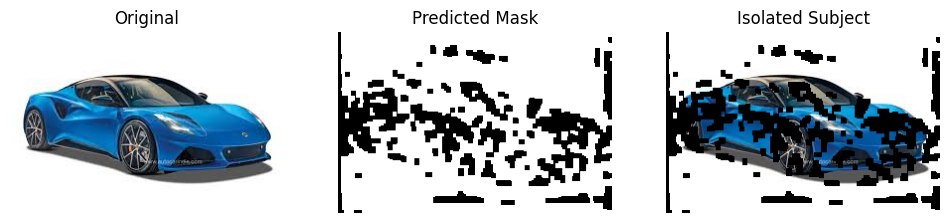

In [26]:
# -------------------- WEEK 6: INFERENCE (SAFE) --------------------
!pip install -q albumentations tqdm segmentation-models-pytorch

import os
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from google.colab import files

# -------------------- DEVICE --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------- PATHS --------------------
MODEL_PATH = "/content/drive/MyDrive/VisionAI/week4_model.pth"
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------- MODEL --------------------
# Use the SAME backbone and encoder weights as Week 5 training
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",  # match your Week 5 training
    in_channels=3,
    classes=1
).to(device)

# Load checkpoint safely
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict, strict=False)  # strict=False avoids key mismatch errors
model.eval()
print("✅ Model loaded safely and ready for inference")

# -------------------- TRANSFORMS --------------------
infer_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# -------------------- INFERENCE FUNCTION --------------------
def isolate_subject(image_path, save_output=True):
    # Load image
    img = np.array(Image.open(image_path).convert("RGB"))
    h, w = img.shape[:2]

    # Preprocess
    augmented = infer_transform(image=img)
    img_tensor = augmented["image"].unsqueeze(0).to(device)

    # Predict mask
    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor)).cpu()[0,0]
    pred_bin = (pred > 0.5).numpy().astype(np.uint8)

    # Resize mask to original size and smooth edges
    pred_bin = cv2.resize(pred_bin, (w, h), interpolation=cv2.INTER_NEAREST)
    pred_bin = cv2.morphologyEx(pred_bin, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))
    pred_bin = cv2.morphologyEx(pred_bin, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

    # Apply mask
    isolated = img * pred_bin[..., None]

    # Save output
    if save_output:
        out_path = os.path.join(OUTPUT_DIR, os.path.basename(image_path))
        Image.fromarray(isolated).save(out_path)
        print(f"✅ Saved isolated subject at: {out_path}")

    # Show results
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(pred_bin, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(isolated); plt.title("Isolated Subject"); plt.axis("off")
    plt.show()

# -------------------- UPLOAD AND RUN --------------------
uploaded = files.upload()  # upload images from your computer

for filename in uploaded.keys():
    isolate_subject(filename)
